In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

df = pd.read_csv('/kaggle/input/datasets/nurulaminchoudhury/sis-fall-multi/output_cleaned.csv')
df

,F1,F2,F3,F4,F5,F6,F7,F8,F9,Fall_Class
0,-9,-257,-25,84,247,27,-120,-987,63,Fall forward while walking caused by a slip
1,-3,-263,-23,99,258,35,-110,-1016,68,Fall forward while walking caused by a slip
2,-1,-270,-22,114,272,45,-94,-1037,69,Fall forward while walking caused by a slip
3,1,-277,-24,127,286,57,-81,-1062,69,Fall forward while walking caused by a slip
4,2,-281,-25,134,303,70,-71,-1079,63,Fall forward while walking caused by a slip
...,...,...,...,...,...,...,...,...,...,...
1048221,-20,-26,14,903,-492,98,-108,-121,73,Fall forward while jogging caused by a trip
1048222,-22,-21,18,939,-518,85,-107,-118,88,Fall forward while jogging caused by a trip
1048223,-25,-17,12,967,-525,79,-132,-87,50,Fall forward while jogging caused by a trip
1048224,-35,-13,-8,964,-504,81,-182,-54,-30,Fall forward while jogging caused by a trip


In [2]:
print(df['Fall_Class'].unique())
print(df[['F1','F2','F3']].head())

['Fall forward while walking caused by a slip'
 'Fall backward while walking caused by a slip'
 'Lateral fall while walking caused by a slip'
 'Fall forward while walking caused by a trip'
 'Fall forward while jogging caused by a trip'
 'Vertical fall while walking caused by fainting'
 'Fall while walking, with use of hands in a table to dampen fall, caused by fainting'
 'Fall forward when trying to get up' 'Lateral fall when trying to get up'
 'Fall forward when trying to sit down'
 'Fall backward when trying to sit down'
 'Lateral fall when trying to sit down'
 'Fall forward while sitting, caused by fainting or falling asleep'
 'Fall backward while sitting, caused by fainting or falling asleep'
 'Lateral fall while sitting, caused by fainting or falling asleep']
   F1   F2  F3
0  -9 -257 -25
1  -3 -263 -23
2  -1 -270 -22
3   1 -277 -24
4   2 -281 -25


In [3]:
df.Fall_Class.unique()

array(['Fall forward while walking caused by a slip',
       'Fall backward while walking caused by a slip',
       'Lateral fall while walking caused by a slip',
       'Fall forward while walking caused by a trip',
       'Fall forward while jogging caused by a trip',
       'Vertical fall while walking caused by fainting',
       'Fall while walking, with use of hands in a table to dampen fall, caused by fainting',
       'Fall forward when trying to get up',
       'Lateral fall when trying to get up',
       'Fall forward when trying to sit down',
       'Fall backward when trying to sit down',
       'Lateral fall when trying to sit down',
       'Fall forward while sitting, caused by fainting or falling asleep',
       'Fall backward while sitting, caused by fainting or falling asleep',
       'Lateral fall while sitting, caused by fainting or falling asleep'],
      dtype=object)

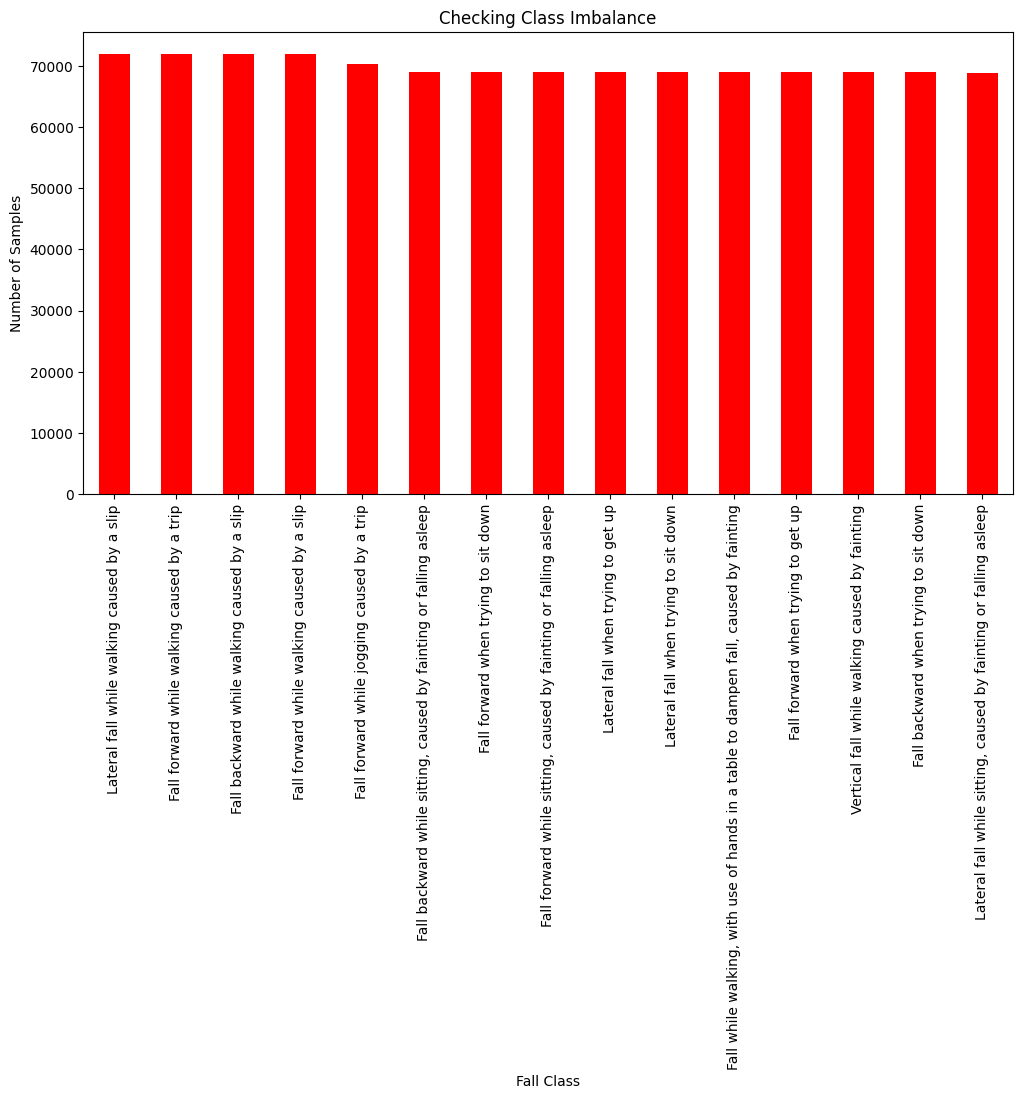

In [4]:
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df['Fall_Class'].value_counts().plot(
    kind='bar',
    title='Checking Class Imbalance',
    color='red'
)
plt.xlabel('Fall Class')
plt.ylabel('Number of Samples')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

# OPTIONAL: drop rows with missing or invalid labels
df = df[df['Fall_Class'].notna()].copy()

# Encode Fall_Class
le = LabelEncoder()
df['Fall_Class_Encoded'] = le.fit_transform(df['Fall_Class'])

# Print label mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("✅ Cleaned Label Mapping (Original → Encoded):")
for k, v in label_mapping.items():
    print(f"{k} → {v}")


✅ Cleaned Label Mapping (Original → Encoded):
Fall backward when trying to sit down → 0
Fall backward while sitting, caused by fainting or falling asleep → 1
Fall backward while walking caused by a slip → 2
Fall forward when trying to get up → 3
Fall forward when trying to sit down → 4
Fall forward while jogging caused by a trip → 5
Fall forward while sitting, caused by fainting or falling asleep → 6
Fall forward while walking caused by a slip → 7
Fall forward while walking caused by a trip → 8
Fall while walking, with use of hands in a table to dampen fall, caused by fainting → 9
Lateral fall when trying to get up → 10
Lateral fall when trying to sit down → 11
Lateral fall while sitting, caused by fainting or falling asleep → 12
Lateral fall while walking caused by a slip → 13
Vertical fall while walking caused by fainting → 14


In [6]:
df

,F1,F2,F3,F4,F5,F6,F7,F8,F9,Fall_Class,Fall_Class_Encoded
0,-9,-257,-25,84,247,27,-120,-987,63,Fall forward while walking caused by a slip,7
1,-3,-263,-23,99,258,35,-110,-1016,68,Fall forward while walking caused by a slip,7
2,-1,-270,-22,114,272,45,-94,-1037,69,Fall forward while walking caused by a slip,7
3,1,-277,-24,127,286,57,-81,-1062,69,Fall forward while walking caused by a slip,7
4,2,-281,-25,134,303,70,-71,-1079,63,Fall forward while walking caused by a slip,7
...,...,...,...,...,...,...,...,...,...,...,...
1048221,-20,-26,14,903,-492,98,-108,-121,73,Fall forward while jogging caused by a trip,5
1048222,-22,-21,18,939,-518,85,-107,-118,88,Fall forward while jogging caused by a trip,5
1048223,-25,-17,12,967,-525,79,-132,-87,50,Fall forward while jogging caused by a trip,5
1048224,-35,-13,-8,964,-504,81,-182,-54,-30,Fall forward while jogging caused by a trip,5


In [7]:
df1 = df.drop(['Fall_Class'], axis=1)

df1.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,Fall_Class_Encoded
0,-9,-257,-25,84,247,27,-120,-987,63,7
1,-3,-263,-23,99,258,35,-110,-1016,68,7
2,-1,-270,-22,114,272,45,-94,-1037,69,7
3,1,-277,-24,127,286,57,-81,-1062,69,7
4,2,-281,-25,134,303,70,-71,-1079,63,7


In [8]:
df1.Fall_Class_Encoded.unique()

array([ 7,  2, 13,  8,  5, 14,  9,  3, 10,  4,  0, 11,  6,  1, 12])

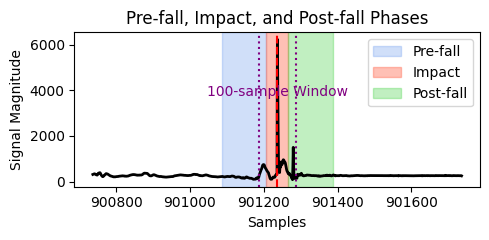

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Accelerometer channels
acc_x = df['F1'].values
acc_y = df['F2'].values
acc_z = df['F3'].values

# Signal Magnitude
smv = np.sqrt(acc_x**2 +
              acc_y**2 +
              acc_z**2)

# Find largest impact
impact_idx = np.argmax(smv)

# Zoom around impact
window = 500

start = max(0, impact_idx-window)
end = min(len(smv), impact_idx+window)

x = np.arange(start, end)
smv_zoom = smv[start:end]

# Define phases
pre_start = impact_idx-150
pre_end = impact_idx-30

impact_start = impact_idx-30
impact_end = impact_idx+30

post_start = impact_idx+30
post_end = impact_idx+150

plt.figure(figsize=(5,2.5))

plt.plot(x,
         smv_zoom,
         color='black',
         linewidth=2)

plt.axvspan(pre_start,
            pre_end,
            alpha=0.3,
            color='cornflowerblue',
            label='Pre-fall')

plt.axvspan(impact_start,
            impact_end,
            alpha=0.4,
            color='tomato',
            label='Impact')

plt.axvspan(post_start,
            post_end,
            alpha=0.3,
            color='limegreen',
            label='Post-fall')

plt.axvline(impact_idx,
            color='red',
            linestyle='--')

# 100-sample window
window_size = 100

seg_start = impact_idx-50
seg_end = impact_idx+50

plt.axvline(seg_start,
            color='purple',
            linestyle=':')

plt.axvline(seg_end,
            color='purple',
            linestyle=':')

plt.text((seg_start+seg_end)/2,
         np.max(smv_zoom)*0.6,
         '100-sample Window',
         color='purple',
         ha='center')

plt.xlabel('Samples')
plt.ylabel('Signal Magnitude')
plt.title('Pre-fall, Impact, and Post-fall Phases')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:

from scipy import stats

# -------------------------------------------------
# Step 2: Segmentation function
# -------------------------------------------------
def create_segments_and_labels(df, time_steps=100, step=10, label_col='Fall_Class_Encoded'):
    # Correct feature columns
    feature_columns = ['F1','F2','F3','F4','F5','F6','F7','F8','F9']

    segments = []
    labels = []

    for i in range(0, len(df) - time_steps, step):
        # Windowed signal: (features, time_steps)
        segment = []
        for col in feature_columns:
            segment.append(df[col].values[i : i + time_steps])

        segment = np.array(segment)  # (9, time_steps)
        segments.append(segment)

        # Majority label in window
        label = stats.mode(
            df[label_col].iloc[i : i + time_steps],
            keepdims=True
        )[0][0]
        labels.append(label)

    # Final shape: (samples, time_steps, features)
    X = np.asarray(segments, dtype=np.float32).transpose(0, 2, 1)
    y = np.asarray(labels)

    return X, y

# -------------------------------------------------
# Step 3: Apply segmentation
# -------------------------------------------------
X, y = create_segments_and_labels(df, time_steps=100, step=10)

# -------------------------------------------------
# Step 4: Verify output
# -------------------------------------------------
print("Segmented Data Shape:", X.shape)   # (N, 200, 9)
print("Labels Shape:", y.shape)           # (N,)
print("Unique Labels:", np.unique(y))
print("Sample Labels:", y[:10])

Segmented Data Shape: (104813, 100, 9)
Labels Shape: (104813,)
Unique Labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Sample Labels: [7 7 7 7 7 7 7 7 7 7]


In [11]:
from sklearn.model_selection import train_test_split

# Step 1: Stratified Train-Test Split
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Step 2: Print dataset shapes
print("Training Data Shape:", X_train_res.shape, "| Labels:", y_train_res.shape)
print("Testing Data Shape :", X_test_res.shape,  "| Labels:", y_test_res.shape)



Training Data Shape: (83850, 100, 9) | Labels: (83850,)
Testing Data Shape : (20963, 100, 9) | Labels: (20963,)


In [12]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf


# Noise Estimation Module
def noise_estimation_module(inputs):
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    noise = layers.Conv1D(1, 3, padding='same', activation='softplus')(x)
    return noise

# Noise-Aware Gating
def noise_aware_gating(features, noise):
    weight = layers.Lambda(lambda x: tf.exp(-x))(noise)
    return layers.Multiply()([features, weight])

# Noise-Aware Transformer Encoder
def noise_aware_transformer_encoder(inputs, noise, head_size, num_heads, ff_dim, dropout=0.01):

    attn = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    # Noise weight
    noise_weight = layers.Lambda(lambda x: tf.exp(-x))(noise)

    # Apply gating
    attn = layers.Multiply()([attn, noise_weight])

    x = layers.Add()([attn, inputs])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Feed Forward
    ffn = keras.Sequential([
        layers.Dense(ff_dim, activation='relu'),
        layers.Dense(inputs.shape[-1])
    ])

    x_ffn = ffn(x)
    x_ffn = layers.Multiply()([x_ffn, noise_weight])

    x = layers.Add()([x_ffn, x])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    return x



# Noise-Aware CNN Block
def noise_aware_cnn_block(inputs, noise, filters, kernel_size):
    x = layers.Conv1D(filters, kernel_size, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = noise_aware_gating(x, noise)
    return x


# NA-MSCT-Net Model
def build_na_msct_net(input_shape=(100, 9), num_classes=15):

    inputs = keras.Input(shape=input_shape)

    # Noise estimation
    noise = noise_estimation_module(inputs)

    # Global CNN
    x = noise_aware_cnn_block(inputs, noise, filters=64, kernel_size=3)

    # Parallel CNN branches
    cnn_branches = [
        noise_aware_cnn_block(x, noise, filters=64, kernel_size=3),
        noise_aware_cnn_block(x, noise, filters=64, kernel_size=5),
        noise_aware_cnn_block(x, noise, filters=64, kernel_size=7)
    ]

    # Transformer
    transformer_out = noise_aware_transformer_encoder(
        x, noise,
        head_size=32,
        num_heads=2,
        ff_dim=64
    )

    # Concatenate
    x = layers.Concatenate()(cnn_branches + [transformer_out])

    # Pooling
    x = layers.GlobalMaxPooling1D()(x)

    # Dense
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="NA-MSCT-Net")

    return model

# Build & Compile
model = build_na_msct_net(input_shape=(100, 9), num_classes=15)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-07-01 06:53:01.713094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782888781.899054      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782888781.949231      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782888782.387043      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782888782.387072      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782888782.387075      57 computation_placer.cc:177] computation placer alr

Model: "NA-MSCT-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 32)   │        896 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 100, 64)   │      1,792 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 1)    │         97 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 100, 1)    │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 100, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     16,640 │ multiply[0][0],   │
│ (MultiHeadAttentio… │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 100, 1)    │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 100, 64)   │          0 │ multi_head_atten… │
│ (Multiply)          │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ multiply_4[0][0], │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 100, 64)   │      8,320 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 100, 64)   │     12,352 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 100, 64)   │     20,544 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 100, 64)   │     28,736 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 100, 64)   │          0 │ sequential[0][0], │
│ (Multiply)          │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 125,616 (490.69 KB)

 Trainable params: 125,040 (488.44 KB)

 Non-trainable params: 576 (2.25 KB)

In [13]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint



# Noise Function
def add_noise(X, noise_level=0.02):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

# Create Noisy Training Data
X_train_noisy = add_noise(X_train_res, noise_level=0.02)


X_combined = np.concatenate([X_train_res, X_train_noisy])
y_combined = np.concatenate([y_train_res, y_train_res])

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    ),
    
    ModelCheckpoint(
        filepath='best_na_msct_model.h5',
        monitor='val_accuracy',
        save_best_only=True
    )
]


history = model.fit(
    X_combined,
    y_combined,
    validation_data=(X_test_res, y_test_res),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    verbose=1)

Epoch 1/100


I0000 00:00:1782888815.949127     128 service.cc:152] XLA service 0x7cbfcc002bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782888815.949201     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782888817.116438     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


  22/1311 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1184 - loss: 2.8943  

I0000 00:00:1782888823.422263     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1311/1311 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2904 - loss: 1.9361

...

1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9918 - loss: 0.0250 - val_accuracy: 0.9753 - val_loss: 0.0991 - learning_rate: 6.2500e-05
Epoch 87/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9916 - loss: 0.0252 - val_accuracy: 0.9748 - val_loss: 0.0991 - learning_rate: 6.2500e-05
Epoch 88/100
1305/1311 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9916 - loss: 0.0254

1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9916 - loss: 0.0254 - val_accuracy: 0.9758 - val_loss: 0.0965 - learning_rate: 6.2500e-05
Epoch 89/100
1305/1311 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9923 - loss: 0.0232

1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9923 - loss: 0.0232 - val_accuracy: 0.9759 - val_loss: 0.0978 - learning_rate: 6.2500e-05
Epoch 90/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9923 - loss: 0.0237 - val_accuracy: 0.9749 - val_loss: 0.0995 - learning_rate: 6.2500e-05
Epoch 91/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9914 - loss: 0.0255 - val_accuracy: 0.9749 - val_loss: 0.0998 - learning_rate: 6.2500e-05
Epoch 92/100
1305/1311 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9925 - loss: 0.0230

1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9925 - loss: 0.0230 - val_accuracy: 0.9760 - val_loss: 0.1000 - learning_rate: 6.2500e-05
Epoch 93/100
1310/1311 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9921 - loss: 0.0246

1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9921 - loss: 0.0246 - val_accuracy: 0.9761 - val_loss: 0.0994 - learning_rate: 6.2500e-05
Epoch 94/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9927 - loss: 0.0223 - val_accuracy: 0.9761 - val_loss: 0.0974 - learning_rate: 3.1250e-05
Epoch 95/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9930 - loss: 0.0222 - val_accuracy: 0.9750 - val_loss: 0.0984 - learning_rate: 3.1250e-05
Epoch 96/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9933 - loss: 0.0207 - val_accuracy: 0.9753 - val_loss: 0.0973 - learning_rate: 3.1250e-05
Epoch 97/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9935 - loss: 0.0210 - val_accuracy: 0.9761 - val_loss: 0.0986 - learning_rate: 3.1250e-05
Epoch 98/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9928 - loss: 0.0214 - val_accuracy: 0.9755 - val_loss: 0.0984 - learning_rate: 3.1250e-05
Epoch 99/100
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s

Test Loss     : 0.0965
Test Accuracy : 97.58%

Classification Report

              precision    recall  f1-score   support

           0     0.9818    0.9768    0.9793      1380
           1     0.9863    0.9899    0.9881      1380
           2     0.9651    0.9591    0.9621      1441
           3     0.9734    0.9812    0.9773      1380
           4     0.9834    0.9855    0.9844      1380
           5     0.9872    0.9837    0.9854      1408
           6     0.9841    0.9884    0.9863      1380
           7     0.9549    0.9715    0.9631      1438
           8     0.9698    0.9597    0.9647      1440
           9     0.9666    0.9652    0.9659      1380
          10     0.9727    0.9819    0.9773      1380
          11     0.9884    0.9855    0.9869      1380
          12     0.9870    0.9891    0.9880      1378
          13     0.9680    0.9659    0.9670      1439
          14     0.9698    0.9550    0.9624      1379

    accuracy                         0.9758     20963
   macro a

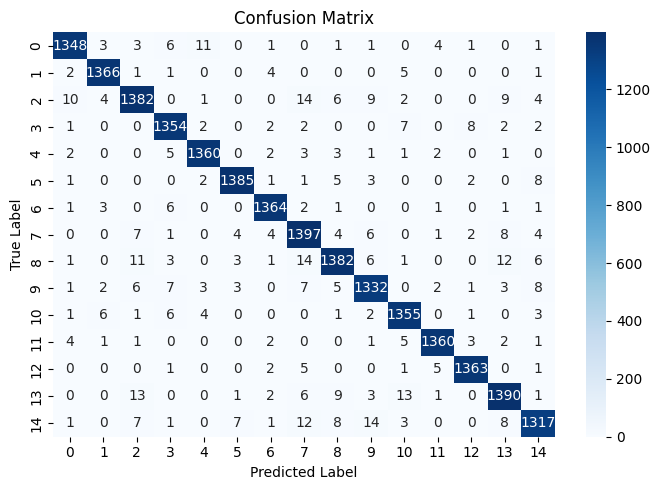

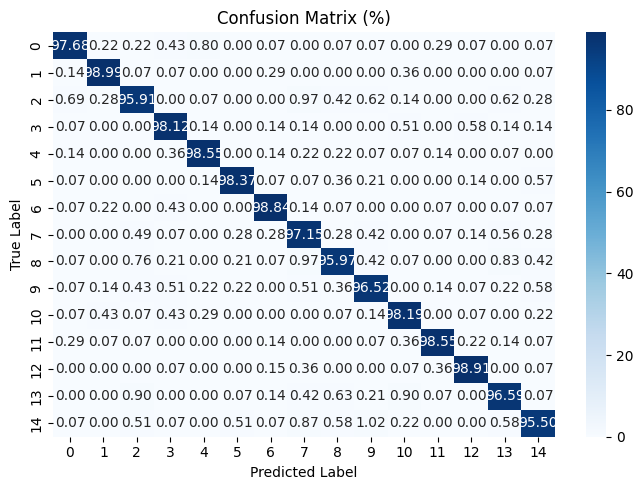


Per-Class Accuracy (%)
----------------------------------------
Class 0: 97.68%
Class 1: 98.99%
Class 2: 95.91%
Class 3: 98.12%
Class 4: 98.55%
Class 5: 98.37%
Class 6: 98.84%
Class 7: 97.15%
Class 8: 95.97%
Class 9: 96.52%
Class 10: 98.19%
Class 11: 98.55%
Class 12: 98.91%
Class 13: 96.59%
Class 14: 95.50%
----------------------------------------
Overall Accuracy: 97.58%


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# -----------------------------
# Test Evaluation
# -----------------------------
test_loss, test_acc = model.evaluate(
    X_test_res,
    y_test_res,
    verbose=0
)

print("="*50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print("="*50)

# -----------------------------
# Predictions
# -----------------------------
y_pred_prob = model.predict(X_test_res, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report\n")

report = classification_report(
    y_test_res,
    y_pred,
    digits=4
)

print(report)

# Optional dataframe version
report_df = pd.DataFrame(
    classification_report(
        y_test_res,
        y_pred,
        output_dict=True
    )
).transpose()

report_df.to_csv("classification_report.csv")

# -----------------------------
# Confusion Matrix (Counts)
# -----------------------------
cm = confusion_matrix(y_test_res, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# -----------------------------
# Confusion Matrix (%)
# Row-wise normalization
# -----------------------------
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cm_percent * 100

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap='Blues'
)

plt.title("Confusion Matrix (%)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# -----------------------------
# Save Percentage Matrix
# -----------------------------
cm_percent_df = pd.DataFrame(cm_percent)

cm_percent_df.to_csv(
    "confusion_matrix_percent.csv",
    index=False
)

# -----------------------------
# Per-Class Accuracy
# -----------------------------
class_accuracy = np.diag(cm) / cm.sum(axis=1)

print("\nPer-Class Accuracy (%)")
print("-"*40)

for idx, acc in enumerate(class_accuracy):
    print(f"Class {idx}: {acc*100:.2f}%")

print("-"*40)
print(f"Overall Accuracy: {accuracy_score(y_test_res, y_pred)*100:.2f}%")

Macro AUC    : 0.9995
Weighted AUC : 0.9995


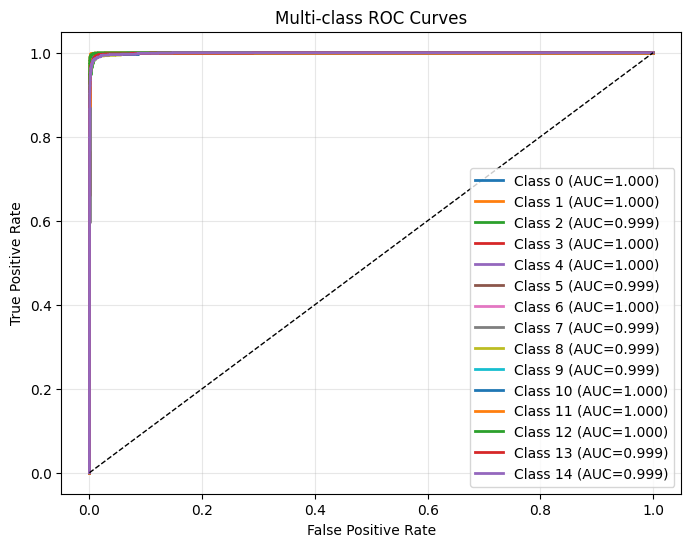

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_prob = model.predict(X_test_res, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Number of classes
n_classes = len(np.unique(y_test_res))

# One-hot encoding
y_test_bin = label_binarize(
    y_test_res,
    classes=np.arange(n_classes)
)

# Macro and Weighted AUC
macro_auc = roc_auc_score(
    y_test_bin,
    y_pred_prob,
    multi_class='ovr',
    average='macro'
)

weighted_auc = roc_auc_score(
    y_test_bin,
    y_pred_prob,
    multi_class='ovr',
    average='weighted'
)

print("="*50)
print(f"Macro AUC    : {macro_auc:.4f}")
print(f"Weighted AUC : {weighted_auc:.4f}")
print("="*50)

# ROC Curves
plt.figure(figsize=(8,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'Class {i} (AUC={roc_auc:.3f})'
    )

plt.plot(
    [0,1],
    [0,1],
    'k--',
    linewidth=1
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

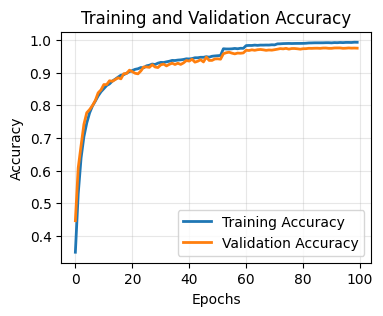

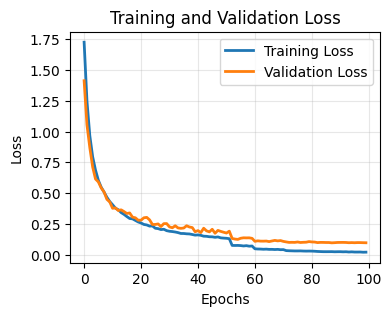

In [17]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(4,3))
plt.plot(
    history.history['accuracy'],
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Loss
plt.figure(figsize=(4,3))
plt.plot(
    history.history['loss'],
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import \
    convert_variables_to_constants_v2

def get_flops(model):

    concrete = tf.function(
        lambda x: model(x)
    ).get_concrete_function(
        tf.TensorSpec(
            [1] + list(model.input_shape[1:]),
            model.inputs[0].dtype
        )
    )

    frozen_func = convert_variables_to_constants_v2(
        concrete
    )

    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(
            graph_def,
            name=''
        )

        run_meta = tf.compat.v1.RunMetadata()

        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops


flops = get_flops(model)

print("="*50)
print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.3f}")
print(f"GFLOPs: {flops/1e9:.6f}")
print("="*50)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


I0000 00:00:1782889849.046292      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782889849.046483      57 single_machine.cc:374] Starting new session
I0000 00:00:1782889849.047421      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


FLOPs : 20,771,122
MFLOPs: 20.771
GFLOPs: 0.020771

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float oper

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import numpy as np
import pandas as pd
import gc
import time

# =====================================================
# SETTINGS
# =====================================================
INPUT_SHAPE = (100, 9)
NUM_CLASSES = len(np.unique(y_train_res))

# =====================================================
# CALLBACKS
# =====================================================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

# =====================================================
# TRANSFORMER BLOCK
# =====================================================
def transformer_block(inputs):

    attn = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32,
        dropout=0.01
    )(inputs, inputs)

    x = layers.Add()([inputs, attn])
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            64,
            activation='relu'
        ),
        layers.Dense(
            inputs.shape[-1]
        )
    ])

    x_ffn = ffn(x)

    x = layers.Add()([x, x_ffn])
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x


# =====================================================
# 1. CNN
# =====================================================
def build_cnn():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='CNN')


# =====================================================
# 2. LSTM
# =====================================================
def build_lstm():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.LSTM(64)(inputs)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='LSTM')


# =====================================================
# 3. BiLSTM
# =====================================================
def build_bilstm():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Bidirectional(
        layers.LSTM(32)
    )(inputs)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='BiLSTM')


# =====================================================
# 4. CNN-LSTM
# =====================================================
def build_cnn_lstm():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.LSTM(64)(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='CNN-LSTM')


# =====================================================
# 5. CNN-BiLSTM
# =====================================================
def build_cnn_bilstm():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(32)
    )(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='CNN-BiLSTM')


# =====================================================
# 6. Transformer
# =====================================================
def build_transformer():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = transformer_block(inputs)

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='Transformer')


# =====================================================
# 7. CNN-Transformer
# =====================================================
def build_cnn_transformer():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    cnn1 = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(x)

    cnn2 = layers.Conv1D(
        64,
        5,
        activation='relu',
        padding='same'
    )(x)

    cnn3 = layers.Conv1D(
        64,
        7,
        activation='relu',
        padding='same'
    )(x)

    trans = transformer_block(x)

    x = layers.Concatenate()(
        [cnn1, cnn2, cnn3, trans]
    )

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name='CNN-Transformer'
    )


# =====================================================
# MODEL DICTIONARY
# =====================================================
models = {
    'CNN': build_cnn,
    'LSTM': build_lstm,
    'BiLSTM': build_bilstm,
    'CNN-LSTM': build_cnn_lstm,
    'CNN-BiLSTM': build_cnn_bilstm,
    'Transformer': build_transformer,
    'CNN-Transformer': build_cnn_transformer
}


histories = {}
trained_models = {}

# =====================================================
# TRAIN ALL MODELS
# =====================================================
for name, builder in models.items():

    print('\n' + '='*70)
    print(f'Training {name}')
    print('='*70)

    tf.keras.backend.clear_session()
    gc.collect()

    model = builder()

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        X_train_res,
        y_train_res,
        validation_data=(
            X_test_res,
            y_test_res
        ),
        epochs=100,
        batch_size=128,
        callbacks=callbacks,
        verbose=1
    )

    end = time.time()

    histories[name] = history
    trained_models[name] = model

    print(
        f'{name} Training Time: '
        f'{(end-start)/60:.2f} mins'
    )


Training CNN
Epoch 1/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2137 - loss: 2.2724 - val_accuracy: 0.2866 - val_loss: 1.8999 - learning_rate: 0.0010
Epoch 2/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2940 - loss: 1.8855 - val_accuracy: 0.3130 - val_loss: 1.8140 - learning_rate: 0.0010
Epoch 3/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3177 - loss: 1.8055 - val_accuracy: 0.3318 - val_loss: 1.7353 - learning_rate: 0.0010
Epoch 4/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3396 - loss: 1.7400 - val_accuracy: 0.3578 - val_loss: 1.6875 - learning_rate: 0.0010
Epoch 5/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3571 - loss: 1.6893 - val_accuracy: 0.3855 - val_loss: 1.6362 - learning_rate: 0.0010
Epoch 6/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3731 - loss: 1.6473 - val_accuracy: 0.3942 - val_loss: 1.6019 - learning_rate: 0.0010
Epoch 7/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3

In [25]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import \
    convert_variables_to_constants_v2


def get_flops(model):

    concrete = tf.function(
        lambda x: model(x)
    ).get_concrete_function(
        tf.TensorSpec(
            [1] + list(model.input_shape[1:]),
            model.inputs[0].dtype
        )
    )

    frozen_func = convert_variables_to_constants_v2(
        concrete
    )

    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:

        tf.graph_util.import_graph_def(
            graph_def,
            name=''
        )

        run_meta = tf.compat.v1.RunMetadata()

        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

In [26]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import time

results = []

for name, model in trained_models.items():

    print('\n' + '='*70)
    print(name)
    print('='*70)

    # -------------------------
    # Evaluation
    # -------------------------
    loss, acc = model.evaluate(
        X_test_res,
        y_test_res,
        verbose=0
    )

    # -------------------------
    # Inference Time
    # -------------------------
    start = time.time()

    y_prob = model.predict(
        X_test_res,
        verbose=0
    )

    inference_time = time.time() - start

    per_sample_time = (
        inference_time /
        len(X_test_res)
    ) * 1000

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    print(
        classification_report(
            y_test_res,
            y_pred,
            digits=4
        )
    )

    # -------------------------
    # AUC
    # -------------------------
    y_test_bin = label_binarize(
        y_test_res,
        classes=np.arange(NUM_CLASSES)
    )

    auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    # -------------------------
    # Parameters
    # -------------------------
    params = model.count_params()

    # -------------------------
    # FLOPs
    # -------------------------
    try:
        flops = get_flops(model)
    except:
        flops = np.nan

    # -------------------------
    # Store Results
    # -------------------------
    results.append({

        'Model': name,

        'Accuracy (%)':
            round(acc*100, 2),

        'Loss':
            round(loss, 4),

        'AUC':
            round(auc, 4),

        'Parameters':
            f'{params:,}',

        'FLOPs':
            f'{flops:,}',

        'MFLOPs':
            round(flops/1e6, 3)
            if not np.isnan(flops)
            else np.nan,

        'Inference (ms/sample)':
            round(per_sample_time, 4)
    })

results_df = pd.DataFrame(results)

print(results_df)

results_df.to_csv(
    'benchmark_results.csv',
    index=False
)


CNN
              precision    recall  f1-score   support

           0     0.7843    0.6957    0.7373      1380
           1     0.8274    0.8058    0.8164      1380
           2     0.6469    0.6447    0.6458      1441
           3     0.7201    0.6638    0.6908      1380
           4     0.6492    0.7725    0.7055      1380
           5     0.8297    0.8821    0.8551      1408
           6     0.7407    0.7616    0.7510      1380
           7     0.5961    0.6662    0.6292      1438
           8     0.6147    0.5826    0.5982      1440
           9     0.6617    0.7072    0.6837      1380
          10     0.7429    0.7036    0.7227      1380
          11     0.7310    0.7304    0.7307      1380
          12     0.7445    0.8164    0.7788      1378
          13     0.6745    0.6206    0.6464      1439
          14     0.6589    0.5547    0.6024      1379

    accuracy                         0.7065     20963
   macro avg     0.7082    0.7072    0.7063     20963
weighted avg     0.70

I0000 00:00:1782562399.255331      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782562399.255543      57 single_machine.cc:374] Starting new session
I0000 00:00:1782562399.256660      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


              precision    recall  f1-score   support

           0     0.7577    0.7094    0.7328      1380
           1     0.7668    0.8101    0.7879      1380
           2     0.5756    0.5545    0.5649      1441
           3     0.7507    0.7399    0.7453      1380
           4     0.7370    0.7413    0.7392      1380
           5     0.8001    0.8104    0.8052      1408
           6     0.7798    0.7674    0.7736      1380
           7     0.5839    0.5904    0.5871      1438
           8     0.6104    0.5854    0.5977      1440
           9     0.5132    0.5790    0.5441      1380
          10     0.7545    0.7348    0.7445      1380
          11     0.7149    0.7558    0.7348      1380
          12     0.8054    0.8287    0.8169      1378
          13     0.6030    0.5900    0.5964      1439
          14     0.5668    0.5228    0.5439      1379

    accuracy                         0.6869     20963
   macro avg     0.6880    0.6880    0.6876     20963
weighted avg     0.6871   

I0000 00:00:1782562404.550486      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782562404.550694      57 single_machine.cc:374] Starting new session
I0000 00:00:1782562404.551803      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


              precision    recall  f1-score   support

           0     0.7944    0.6971    0.7426      1380
           1     0.8046    0.8087    0.8066      1380
           2     0.6039    0.5344    0.5670      1441
           3     0.7065    0.7065    0.7065      1380
           4     0.6699    0.7558    0.7102      1380
           5     0.7716    0.7798    0.7757      1408
           6     0.7415    0.6674    0.7025      1380
           7     0.5343    0.6398    0.5823      1438
           8     0.5594    0.5528    0.5561      1440
           9     0.5826    0.5775    0.5801      1380
          10     0.7697    0.7435    0.7564      1380
          11     0.6770    0.7580    0.7152      1380
          12     0.7798    0.8251    0.8018      1378
          13     0.6157    0.5455    0.5785      1439
          14     0.5682    0.5620    0.5651      1379

    accuracy                         0.6758     20963
   macro avg     0.6786    0.6769    0.6764     20963
weighted avg     0.6776   

...

I0000 00:00:1782562424.142439      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782562424.142676      57 single_machine.cc:374] Starting new session
I0000 00:00:1782562424.143748      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

I0000 00:00:1782562427.358020      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782562427.358212      57 single_machine.cc:374] Starting new session
I0000 00:00:1782562427.359203      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



CNN-Transformer

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the impl

I0000 00:00:1782562430.911943      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782562430.912188      57 single_machine.cc:374] Starting new session
I0000 00:00:1782562430.913230      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [27]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

results = []

for name, model in trained_models.items():

    print('\n' + '='*70)
    print(name)
    print('='*70)

    loss, acc = model.evaluate(
        X_test_res,
        y_test_res,
        verbose=0
    )

    y_prob = model.predict(
        X_test_res,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    print(
        classification_report(
            y_test_res,
            y_pred,
            digits=4
        )
    )

    y_test_bin = label_binarize(
        y_test_res,
        classes=np.arange(NUM_CLASSES)
    )

    auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    params = model.count_params()

    results.append({
        'Model': name,
        'Accuracy': acc*100,
        'Loss': loss,
        'AUC': auc,
        'Parameters': params
    })

results_df = pd.DataFrame(results)

print(results_df)

results_df.to_csv(
    'benchmark_results.csv',
    index=False
)


CNN
              precision    recall  f1-score   support

           0     0.7843    0.6957    0.7373      1380
           1     0.8274    0.8058    0.8164      1380
           2     0.6469    0.6447    0.6458      1441
           3     0.7201    0.6638    0.6908      1380
           4     0.6492    0.7725    0.7055      1380
           5     0.8297    0.8821    0.8551      1408
           6     0.7407    0.7616    0.7510      1380
           7     0.5961    0.6662    0.6292      1438
           8     0.6147    0.5826    0.5982      1440
           9     0.6617    0.7072    0.6837      1380
          10     0.7429    0.7036    0.7227      1380
          11     0.7310    0.7304    0.7307      1380
          12     0.7445    0.8164    0.7788      1378
          13     0.6745    0.6206    0.6464      1439
          14     0.6589    0.5547    0.6024      1379

    accuracy                         0.7065     20963
   macro avg     0.7082    0.7072    0.7063     20963
weighted avg     0.70

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import gc

NUM_CLASSES = len(np.unique(y_train_res))
INPUT_SHAPE = X_train_res.shape[1:]

# ======================================================
# Modules
# ======================================================
def noise_estimation_module(inputs):
    x = layers.Conv1D(
        32,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    x = layers.BatchNormalization()(x)

    noise = layers.Conv1D(
        1,
        3,
        padding='same',
        activation='softplus'
    )(x)

    return noise


def noise_aware_gating(features, noise):
    weight = layers.Lambda(
        lambda x: tf.exp(-x)
    )(noise)

    return layers.Multiply()([features, weight])


def transformer_encoder(
    inputs,
    noise=None,
    use_noise=False
):

    attn = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32,
        dropout=0.01
    )(inputs, inputs)

    if use_noise:
        weight = layers.Lambda(
            lambda x: tf.exp(-x)
        )(noise)

        attn = layers.Multiply()(
            [attn, weight]
        )

    x = layers.Add()([inputs, attn])
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            64,
            activation='relu'
        ),
        layers.Dense(
            inputs.shape[-1]
        )
    ])

    x_ffn = ffn(x)

    if use_noise:
        x_ffn = layers.Multiply()(
            [x_ffn, weight]
        )

    x = layers.Add()([x, x_ffn])

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x


# ======================================================
# Ablation Model Builder
# ======================================================
def build_model(
    use_nem=False,
    use_cnn_gate=False,
    use_trans_gate=False
):

    inputs = keras.Input(
        shape=INPUT_SHAPE
    )

    noise = None

    if use_nem:
        noise = noise_estimation_module(
            inputs
        )

    # Global CNN
    x = layers.Conv1D(
        64,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    x = layers.BatchNormalization()(x)

    if use_cnn_gate and noise is not None:
        x = noise_aware_gating(
            x,
            noise
        )

    branches = []

    for k in [3,5,7]:

        b = layers.Conv1D(
            64,
            k,
            padding='same',
            activation='relu'
        )(x)

        b = layers.BatchNormalization()(b)

        if use_cnn_gate and noise is not None:
            b = noise_aware_gating(
                b,
                noise
            )

        branches.append(b)

    transformer = transformer_encoder(
        x,
        noise=noise,
        use_noise=use_trans_gate
    )

    x = layers.Concatenate()(
        branches + [transformer]
    )

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(
        inputs,
        outputs
    )


# ======================================================
# Ablation Settings
# ======================================================
settings = {
    'Baseline':
        (False, False, False),

    '+NEM':
        (True, False, False),

    '+NAG':
        (True, True, False),

    '+NATE':
        (True, False, True),

    '+NAG + NATE':
        (True, True, True)
}


results = []

baseline_acc = None

for name, config in settings.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_model(*config)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_res,
        y_train_res,
        validation_data=(
            X_test_res,
            y_test_res
        ),
        epochs=100,
        batch_size=128,
        verbose=1
    )

    y_prob = model.predict(
        X_test_res,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    acc = accuracy_score(
        y_test_res,
        y_pred
    ) * 100

    f1 = f1_score(
        y_test_res,
        y_pred,
        average='macro'
    ) * 100

    y_test_bin = label_binarize(
        y_test_res,
        classes=np.arange(NUM_CLASSES)
    )

    auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    if baseline_acc is None:
        baseline_acc = acc

    delta = acc - baseline_acc

    results.append({
        'Setting': name,
        'Acc (%)': round(acc,2),
        'F1-score (%)': round(f1,2),
        'AUC': round(auc,4),
        'ΔAcc (%)': round(delta,2)
    })

    del model
    gc.collect()
    tf.keras.backend.clear_session()

ablation_df = pd.DataFrame(results)

print(ablation_df)



2026-06-28 10:36:49.266945: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782643009.462857      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782643009.523208      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782643010.011855      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782643010.011891      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782643010.011894      57 computation_placer.cc:177] computation placer alr


Baseline


I0000 00:00:1782643034.312707      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/100


I0000 00:00:1782643041.322599     153 service.cc:152] XLA service 0x79c374003d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782643041.322639     153 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782643042.321130     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


 24/656 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1560 - loss: 3.0737 

I0000 00:00:1782643047.901277     153 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


656/656 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.2578 - loss: 2.1022 - val_accuracy: 0.3557 - val_loss: 1.6876
Epoch 2/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3754 - loss: 1.6429 - val_accuracy: 0.4303 - val_loss: 1.4763
Epoch 3/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4442 - loss: 1.4528 - val_accuracy: 0.5051 - val_loss: 1.2805
Epoch 4/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5322 - loss: 1.2391 - val_accuracy: 0.5758 - val_loss: 1.1332
Epoch 5/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5841 - loss: 1.1062 - val_accuracy: 0.6442 - val_loss: 0.9713
Epoch 6/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6297 - loss: 0.9900 - val_accuracy: 0.6752 - val_loss: 0.8778
Epoch 7/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6598 - loss: 0.9109 - val_accuracy: 0.6702 - val_loss: 0.8748
Epoch 8/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6825 - loss: 0.8517 - val_accuracy: 0.70

Loss Ablation

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import gc

NUM_CLASSES = len(np.unique(y_train_res))
INPUT_SHAPE = X_train_res.shape[1:]

# ======================================================
# Noise Estimation Module
# ======================================================
def noise_estimation_module(inputs):

    x = layers.Conv1D(
        32,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    x = layers.BatchNormalization()(x)

    noise = layers.Conv1D(
        1,
        3,
        padding='same',
        activation='softplus'
    )(x)

    return noise


# ======================================================
# Noise-Aware Gating
# ======================================================
def noise_aware_gating(features, noise):

    weight = layers.Lambda(
        lambda x: tf.exp(-x)
    )(noise)

    return layers.Multiply()(
        [features, weight]
    )


# ======================================================
# Transformer Encoder
# ======================================================
def transformer_encoder(
    inputs,
    noise=None,
    use_noise=False
):

    attn = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32,
        dropout=0.01
    )(inputs, inputs)

    if use_noise:

        weight = layers.Lambda(
            lambda x: tf.exp(-x)
        )(noise)

        attn = layers.Multiply()(
            [attn, weight]
        )

    x = layers.Add()([inputs, attn])

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            64,
            activation='relu'
        ),
        layers.Dense(
            inputs.shape[-1]
        )
    ])

    x_ffn = ffn(x)

    if use_noise:
        x_ffn = layers.Multiply()(
            [x_ffn, weight]
        )

    x = layers.Add()([x, x_ffn])

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x


# ======================================================
# Ablation Model Builder
# ======================================================
def build_model(
    use_nem=False,
    use_cnn_gate=False,
    use_trans_gate=False
):

    inputs = keras.Input(
        shape=INPUT_SHAPE
    )

    noise = None

    if use_nem:
        noise = noise_estimation_module(
            inputs
        )

    # Global CNN
    x = layers.Conv1D(
        64,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    x = layers.BatchNormalization()(x)

    if use_cnn_gate and noise is not None:
        x = noise_aware_gating(
            x,
            noise
        )

    branches = []

    for k in [3, 5, 7]:

        b = layers.Conv1D(
            64,
            k,
            padding='same',
            activation='relu'
        )(x)

        b = layers.BatchNormalization()(b)

        if use_cnn_gate and noise is not None:
            b = noise_aware_gating(
                b,
                noise
            )

        branches.append(b)

    transformer = transformer_encoder(
        x,
        noise=noise,
        use_noise=use_trans_gate
    )

    x = layers.Concatenate()(
        branches + [transformer]
    )

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(
        inputs,
        outputs
    )


# ======================================================
# Ablation Settings
# ======================================================
settings = {
    'Baseline':
        (False, False, False),

    '+NEM':
        (True, False, False),

    '+NAG':
        (True, True, False),

    '+NATE':
        (True, False, True),

    '+NAG + NATE':
        (True, True, True)
}


# ======================================================
# Run Ablation
# ======================================================
results = []

baseline_acc = None

for name, config in settings.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_model(*config)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_res,
        y_train_res,
        validation_data=(
            X_test_res,
            y_test_res
        ),
        epochs=100,
        batch_size=128,
        verbose=1
    )

    # ==================================================
    # Test Evaluation
    # ==================================================
    test_loss, test_acc = model.evaluate(
        X_test_res,
        y_test_res,
        verbose=0
    )

    y_prob = model.predict(
        X_test_res,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    acc = accuracy_score(
        y_test_res,
        y_pred
    ) * 100

    f1 = f1_score(
        y_test_res,
        y_pred,
        average='macro'
    ) * 100

    y_test_bin = label_binarize(
        y_test_res,
        classes=np.arange(NUM_CLASSES)
    )

    auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    if baseline_acc is None:
        baseline_acc = acc

    delta = acc - baseline_acc

    results.append({
        'Setting': name,
        'Acc (%)': round(acc, 2),
        'F1-score (%)': round(f1, 2),
        'Loss': round(test_loss, 4),
        'AUC': round(auc, 4),
        'ΔAcc (%)': round(delta, 2)
    })

    del model
    gc.collect()
    tf.keras.backend.clear_session()


# ======================================================
# Final Results
# ======================================================
ablation_df = pd.DataFrame(results)

print("\n")
print(ablation_df)

ablation_df.to_csv(
    'ablation_results.csv',
    index=False
)

2026-06-28 18:55:47.716952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782672947.899597      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782672947.958474      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782672948.406550      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782672948.406578      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782672948.406581      57 computation_placer.cc:177] computation placer alr


Baseline


I0000 00:00:1782672971.269154      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/100


I0000 00:00:1782672978.201603     137 service.cc:152] XLA service 0x797cac0027d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782672978.201668     137 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782672979.186452     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


 24/656 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1458 - loss: 3.3196 

I0000 00:00:1782672984.665642     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


656/656 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.2563 - loss: 2.1331 - val_accuracy: 0.3567 - val_loss: 1.6817
Epoch 2/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3666 - loss: 1.6532 - val_accuracy: 0.4483 - val_loss: 1.4581
Epoch 3/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4425 - loss: 1.4589 - val_accuracy: 0.5018 - val_loss: 1.3096
Epoch 4/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5088 - loss: 1.2971 - val_accuracy: 0.5629 - val_loss: 1.1585
Epoch 5/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5696 - loss: 1.1294 - val_accuracy: 0.6411 - val_loss: 0.9719
Epoch 6/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6244 - loss: 0.9980 - val_accuracy: 0.6381 - val_loss: 0.9620
Epoch 7/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6484 - loss: 0.9357 - val_accuracy: 0.6814 - val_loss: 0.8497
Epoch 8/100
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6855 - loss: 0.8316 - val_accuracy: 0.70